<a href="https://colab.research.google.com/github/Sahana1909/Data-Visualization/blob/main/DVEx5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving household_power_consumption.csv to household_power_consumption.csv


Column Names:
Index(['index', 'Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

DateTime Created Successfully
     Date     Time DateTime  Hour
0  1/1/07  0:00:00      NaT   NaN
1  1/1/07  0:01:00      NaT   NaN
2  1/1/07  0:02:00      NaT   NaN
3  1/1/07  0:03:00      NaT   NaN
4  1/1/07  0:04:00      NaT   NaN


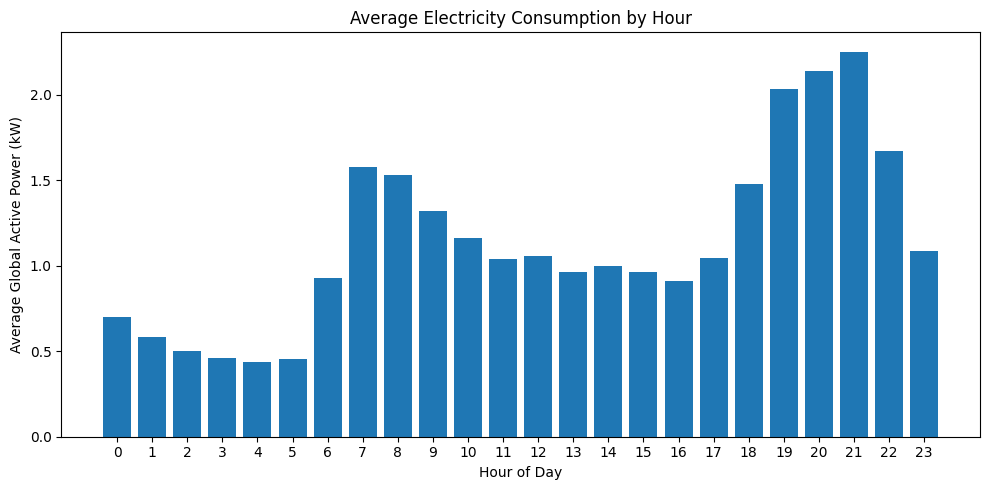

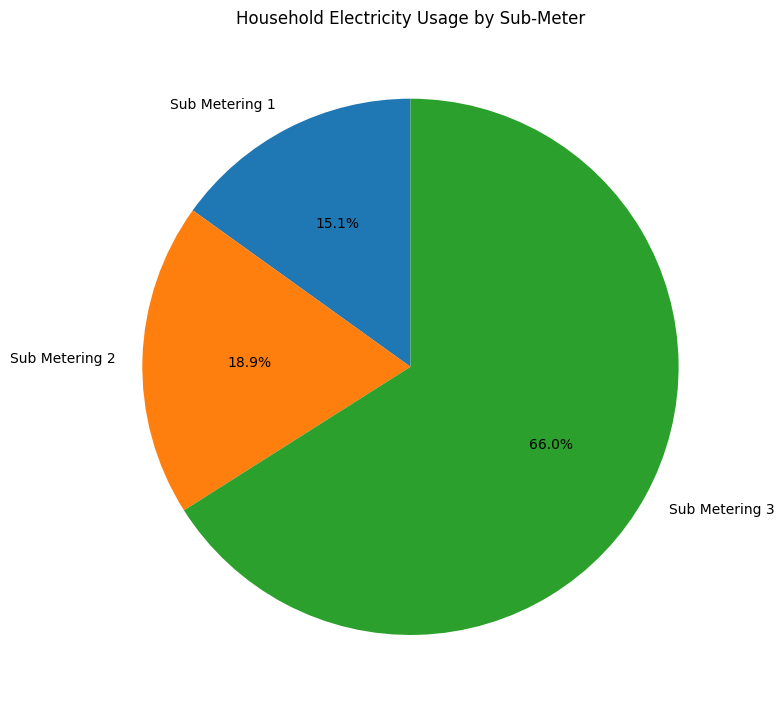

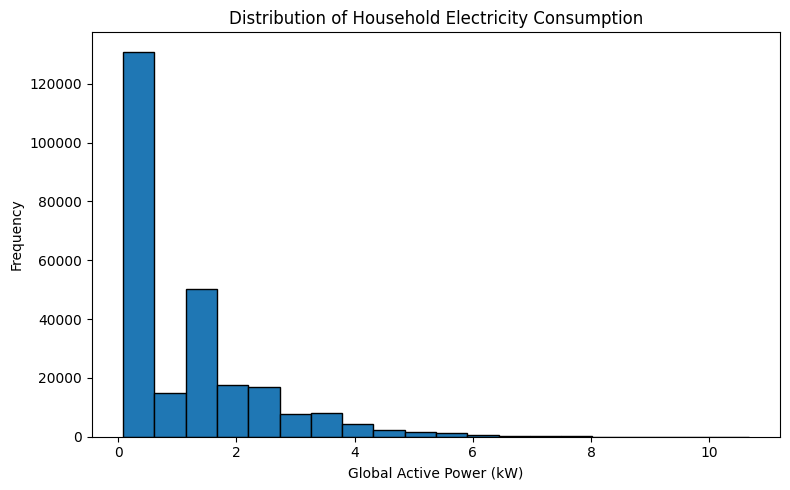

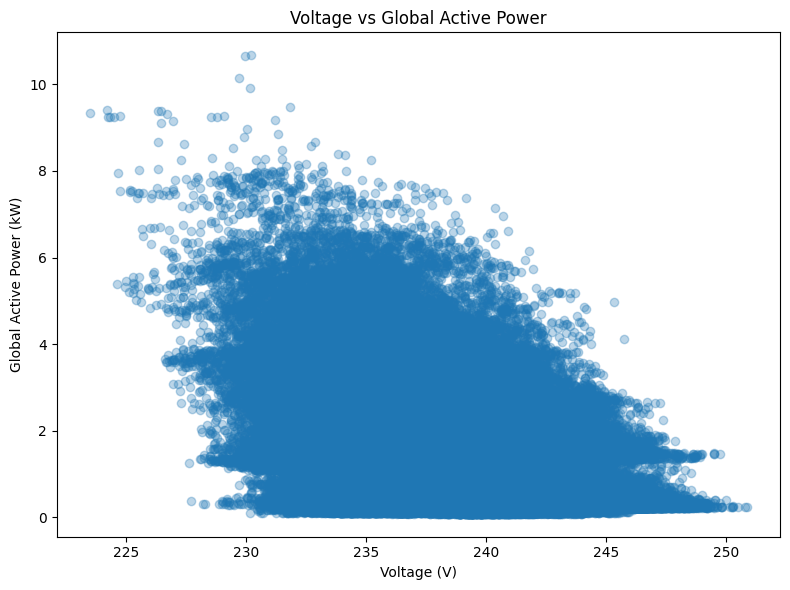

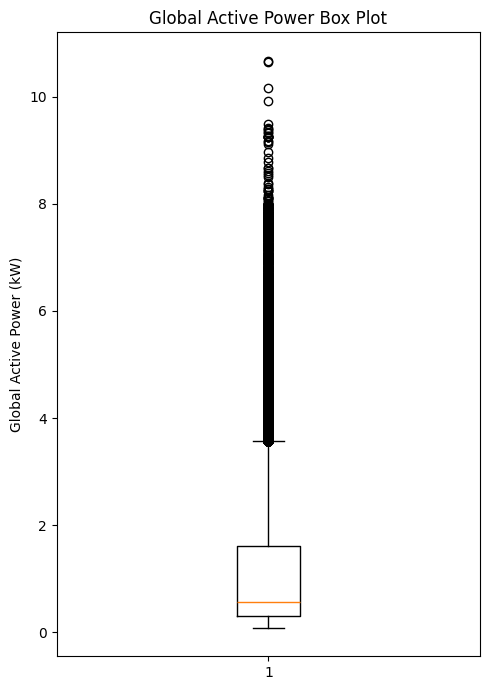

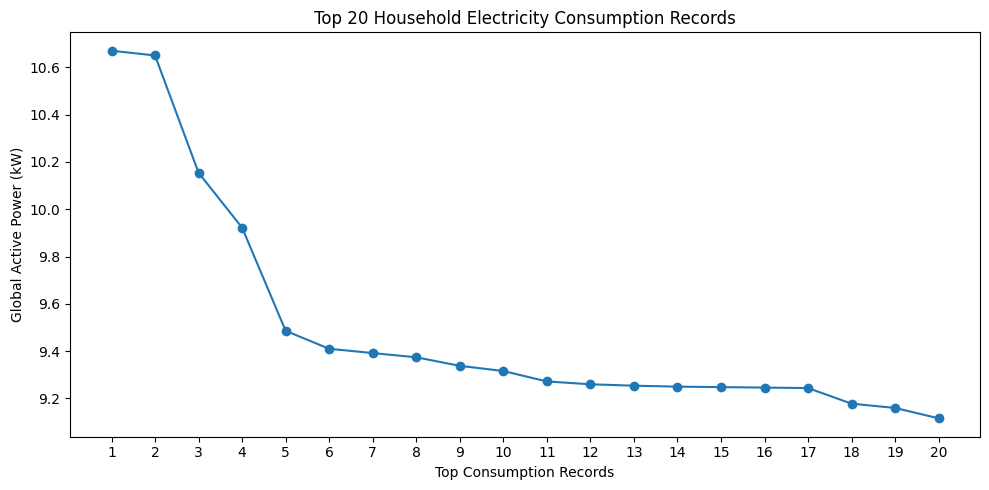

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# READ ELECTRICITY DATASET
# ============================================================

df = pd.read_csv(
    "household_power_consumption.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Column Names:")
print(df.columns)


# ============================================================
# CONVERT ELECTRICITY COLUMNS TO NUMERIC
# ============================================================

numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# CREATE DATETIME
# Date format = DD/MM/YYYY
# ============================================================

df["DateTime"] = pd.to_datetime(
    df["Date"].astype(str).str.strip() + " " +
    df["Time"].astype(str).str.strip(),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# Extract hour
df["Hour"] = df["DateTime"].dt.hour

print("\nDateTime Created Successfully")
print(df[["Date", "Time", "DateTime", "Hour"]].head())


# ============================================================
# REMOVE INVALID VALUES FOR VISUALIZATION
# ============================================================

df_clean = df.dropna(
    subset=[
        "Global_active_power",
        "Voltage",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]
)


# ============================================================
# 1. BAR CHART
# Average Electricity Consumption by Hour
# ============================================================

hourly_power = df_clean.groupby(
    "Hour"
)["Global_active_power"].mean()

plt.figure(figsize=(10,5))

plt.bar(
    hourly_power.index,
    hourly_power.values
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power (kW)")

plt.title(
    "Average Electricity Consumption by Hour"
)

plt.xticks(range(24))

plt.tight_layout()
plt.show()


# ============================================================
# 2. PIE CHART
# Household Electricity Usage by Sub-Meter
# ============================================================

meter_usage = [
    df_clean["Sub_metering_1"].sum(),
    df_clean["Sub_metering_2"].sum(),
    df_clean["Sub_metering_3"].sum()
]

labels = [
    "Sub Metering 1",
    "Sub Metering 2",
    "Sub Metering 3"
]

plt.figure(figsize=(8,8))

plt.pie(
    meter_usage,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Household Electricity Usage by Sub-Meter"
)

plt.tight_layout()
plt.show()


# ============================================================
# 3. HISTOGRAM
# Distribution of Electricity Consumption
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    df_clean["Global_active_power"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Global Active Power (kW)")
plt.ylabel("Frequency")

plt.title(
    "Distribution of Household Electricity Consumption"
)

plt.tight_layout()
plt.show()


# ============================================================
# 4. SCATTER PLOT
# Voltage vs Global Active Power
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df_clean["Voltage"],
    df_clean["Global_active_power"],
    alpha=0.3
)

plt.xlabel("Voltage (V)")
plt.ylabel("Global Active Power (kW)")

plt.title(
    "Voltage vs Global Active Power"
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. BOX PLOT
# Global Active Power
# ============================================================

plt.figure(figsize=(5,7))

plt.boxplot(
    df_clean["Global_active_power"]
)

plt.title(
    "Global Active Power Box Plot"
)

plt.ylabel(
    "Global Active Power (kW)"
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. LINE PLOT
# Top 20 Highest Electricity Consumption Records
# ============================================================

top = df_clean.nlargest(
    20,
    "Global_active_power"
)

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(top) + 1),
    top["Global_active_power"],
    marker="o"
)

plt.xlabel(
    "Top Consumption Records"
)

plt.ylabel(
    "Global Active Power (kW)"
)

plt.title(
    "Top 20 Household Electricity Consumption Records"
)

plt.xticks(range(1, len(top) + 1))

plt.tight_layout()
plt.show()